# Analysis accuracy against adjudicated labels

Evaluates `fastpath` and `analysis_web_measurement` against a labeller export,
and computes per-rule log-likelihood ratios — the numbers that will eventually
replace the hand-set `(blocked, down, ok)` constants in `analysis/rules.py`.

Inputs: a labels JSON export from `docs/labeler.html`, and ClickHouse on
`localhost:9000` with this repo's tables.

Read the numbers with their intervals. The corpus is a few dozen labels;
point estimates alone will overfit your intuition long before they overfit
a model.

In [27]:
import json
import numpy as np
import pandas as pd
import altair as alt
from clickhouse_driver import Client
from glob import glob
alt.renderers.enable('mimetype')

alt.data_transformers.disable_max_rows()
pd.options.display.max_columns = None

LABELS_PATH_GLOB = "labels/2026-08-03-measurement-labels-*.json"
CLICKHOUSE = dict(host="localhost", port=9000)  # ssh tunnel to the data node
DATABASE = "ooni"

rng = np.random.default_rng(2026)
client = Client(**CLICKHOUSE)

## 1. Load labels

Only live labels count (`superseded_by` null), one per measurement. Everything
else is history the labeller keeps on purpose.

In [8]:
label_exports = []
for labels_path in glob(LABELS_PATH_GLOB):
    label_exports.append(json.load(open(labels_path)))

designs = {}
labels = []
for export in label_exports:
    designs.update(export["sampling_designs"])
    labels += [l for l in export["labels"] if not l["superseded_by"]]
labels = pd.DataFrame(labels)
assert labels.measurement_uid.is_unique, "more than one live label per measurement"

labels["truth"] = labels.label.map({"blocked": True, "ok": False, "down": False})
dropped = labels[labels.truth.isna()]
if len(dropped):
    print(f"dropping {len(dropped)} unadjudicated/unusable labels")
labels = labels.dropna(subset=["truth"]).copy()
labels["truth"] = labels.truth.astype(bool)

labels.groupby(["sampling_stratum", "label"]).size().unstack(fill_value=0)

dropping 3 unadjudicated/unusable labels


label,blocked,down,ok
sampling_stratum,,,
screen_negative,3,2,75
screen_positive,42,0,4


## 2. Recompute sampling weights

Stored weights are whatever the labeller build of the day wrote (the oldest
labels carry `1/sample_rate`, which was wrong). Recomputed here from the design
records instead, with two corrections:

- **Replicated draws pool.** Designs sharing a stratum predicate and frame are
  disjoint samples of the same population, so their labels pool with
  `weight = population / n_labelled` over the pooled group.
- **The denominator is labels, not queue rows.** A queue is a hash-ordered
  random permutation, so the labelled prefix is still a uniform sample — but
  its size is what sets the inclusion probability, not the 20 rows drawn.

In [9]:
def stratum_groups(designs):
    groups = {}
    for did, d in designs.items():
        for name, s in d["strata"].items():
            key = (s["predicate"], s["frame_start"], s["frame_end"])
            g = groups.setdefault(key, {"stratum": name, "populations": [], "members": set()})
            g["populations"].append(s["population_estimate"])
            g["members"].add((did, name))
    return groups

groups = stratum_groups(designs)
member_to_key = {m: key for key, g in groups.items() for m in g["members"]}

labels["group_key"] = [
    member_to_key[(r.sampling_design_id, r.sampling_stratum)] for r in labels.itertuples()
]
n_labelled = labels.groupby("group_key").size()

rows = []
for key, g in groups.items():
    n = int(n_labelled.get(key, 0))
    pop = float(np.mean(g["populations"]))
    rows.append({
        "group_key": key, "stratum": g["stratum"], "population": pop,
        "designs": len(g["members"]), "n_labelled": n,
        "weight": pop / n if n else np.nan,
    })
weights = pd.DataFrame(rows).set_index("group_key")

labels["w"] = labels.group_key.map(weights.weight)
weights[["stratum", "population", "designs", "n_labelled", "weight"]]

,stratum,population,designs,n_labelled,weight
group_key,,,,,
"(confirmed = 'f' AND anomaly = 'f' AND msm_failure = 'f', 2026-07-01T00:00:00, 2026-07-31T00:00:00)",screen_negative,44215420.0,2,2,2.210771e+07
"(anomaly = 't' AND msm_failure = 'f', 2026-07-01T00:00:00, 2026-07-31T00:00:00)",screen_positive,4276510.0,2,0,NaN
"(confirmed = 'f' AND anomaly = 'f' AND msm_failure = 'f', 2026-07-04T00:00:00, 2026-08-03T00:00:00)",screen_negative,44159758.5,2,59,7.484705e+05
"(anomaly = 't' AND msm_failure = 'f', 2026-07-04T00:00:00, 2026-08-03T00:00:00)",screen_positive,4313447.0,2,20,2.156724e+05
"(anomaly = 't' AND msm_failure = 'f', 2026-07-03T00:00:00, 2026-08-04T00:00:00)",screen_positive,4587680.0,2,26,1.764492e+05
"(confirmed = 'f' AND anomaly = 'f' AND msm_failure = 'f', 2026-07-03T00:00:00, 2026-08-04T00:00:00)",screen_negative,47088275.0,1,19,2.478330e+06


A weighted total is an estimate of a population count: each blocked label in
`screen_positive` stands for `weight` measurements that fastpath flagged the
same way. The first sanity check is prevalence — the share of all July
web_connectivity measurements that were actually blocked.

In [10]:
def wilson(k, n, z=1.96):
    """Wilson interval on a plain proportion. Used where the sample is
    uniform within one stratum, so no weights are involved."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    d = 1 + z**2 / n
    c = p + z**2 / (2 * n)
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return ((c - h) / d, (c + h) / d)

def boot(frame, stat, reps=2000):
    """Percentile bootstrap, resampling labels within each stratum group so
    the design stays fixed and only sampling noise varies."""
    out = []
    parts = [g for _, g in frame.groupby("group_key")]
    for _ in range(reps):
        rs = pd.concat([p.sample(len(p), replace=True, random_state=rng.integers(2**32)) for p in parts])
        out.append(stat(rs))
    return np.nanpercentile(out, [2.5, 97.5])

prevalence = lambda f: f.w[f.truth].sum() / f.w.sum()
lo, hi = boot(labels, prevalence)
print(f"estimated blocked prevalence: {prevalence(labels):.2%}  (95% CI {lo:.2%}-{hi:.2%})")

estimated blocked prevalence: 8.35%  (95% CI 5.60%-12.51%)


## 3. Fastpath accuracy

The screen strata condition on fastpath's own verdict, which makes two numbers
available without weights at all: within `screen_positive` the share of true
blocking *is* the precision of `anomaly = 't'`, and within `screen_negative`
the share of benign rows is the NPV of the quiet flag. Sensitivity and
specificity cut across strata, so they need the weights.

In [11]:
# The stratum was assigned from fastpath at draw time; confirm fastpath still
# says the same thing, since a rescore between draw and evaluation would move
# labels between strata and quietly break the weights.
fp = pd.DataFrame(client.execute(f'''
    SELECT measurement_uid, anomaly, confirmed, msm_failure
    FROM {DATABASE}.fastpath
    WHERE measurement_uid IN %(uids)s
''', {"uids": labels.measurement_uid.tolist()}),
    columns=["measurement_uid", "anomaly", "confirmed", "msm_failure"])
chk = labels.merge(fp, on="measurement_uid", how="left")
chk["stratum_now"] = np.where(chk.anomaly.isna(), "missing",
                     np.where(chk.anomaly == "t", "screen_positive", "screen_negative"))
drift = chk[chk.stratum_now != chk.sampling_stratum]
if len(drift):
    print("stratum drift since draw -- weights for these are suspect:")
    display(drift[["measurement_uid", "sampling_stratum", "stratum_now"]])
else:
    print(f"fastpath flags unchanged since draw for all {len(chk)} labels")

fastpath flags unchanged since draw for all 126 labels


In [12]:
pos = labels[labels.sampling_stratum == "screen_positive"]
neg = labels[labels.sampling_stratum == "screen_negative"]

k, n = int(pos.truth.sum()), len(pos)
print(f"P(blocked | anomaly)      = {k}/{n} = {k/n:.0%}   Wilson {wilson(k,n)[0]:.0%}-{wilson(k,n)[1]:.0%}")
k, n = int((~neg.truth).sum()), len(neg)
print(f"P(benign  | not flagged)  = {k}/{n} = {k/n:.0%}   Wilson {wilson(k,n)[0]:.0%}-{wilson(k,n)[1]:.0%}")

sens = lambda f: f.w[f.truth & (f.sampling_stratum == "screen_positive")].sum() / f.w[f.truth].sum()
spec = lambda f: f.w[~f.truth & (f.sampling_stratum == "screen_negative")].sum() / f.w[~f.truth].sum()
for name, stat in [("sensitivity of anomaly='t'", sens), ("specificity", spec)]:
    lo, hi = boot(labels, stat)
    print(f"{name:26s} = {stat(labels):.1%}   (95% CI {lo:.1%}-{hi:.1%})")

P(blocked | anomaly)      = 42/46 = 91%   Wilson 80%-97%
P(benign  | not flagged)  = 77/80 = 96%   Wilson 90%-99%
sensitivity of anomaly='t' = 67.0%   (95% CI 44.8%-100.0%)
specificity                = 99.4%   (95% CI 98.7%-99.9%)


The sensitivity number is the one to watch: a blocked measurement inside
`screen_negative` carries a weight in the millions, so a single one (like the
CN `tls.reset.other` case here) drags estimated sensitivity down hard while its
interval stays enormous. That is not a defect of the estimator — it is what
one false negative in a 44M-row stratum genuinely implies. Label more
`screen_negative` rows to shrink it.

## 4. Pipeline (`analysis_web_measurement`) accuracy

`FINAL` collapses any not-yet-merged duplicates from reprocessing. The verdict
proxy is `greatest(dns, tcp, tls blocked) >= t`, the same shape the old
loni screen used; the sweep shows how the operating point moves with `t`.

In [13]:
uids = labels.measurement_uid.tolist()
awm = pd.DataFrame(client.execute(f'''
    SELECT measurement_uid,
           dns_blocked, dns_down, dns_ok, top_dns_rule_id,
           tcp_blocked, tcp_down, tcp_ok, top_tcp_rule_id,
           tls_blocked, tls_down, tls_ok, top_tls_rule_id
    FROM {DATABASE}.analysis_web_measurement FINAL
    WHERE measurement_uid IN %(uids)s
''', {"uids": uids}), columns=[
    "measurement_uid",
    "dns_blocked", "dns_down", "dns_ok", "top_dns_rule_id",
    "tcp_blocked", "tcp_down", "tcp_ok", "top_tcp_rule_id",
    "tls_blocked", "tls_down", "tls_ok", "top_tls_rule_id",
])
ev = labels.merge(awm, on="measurement_uid", how="left")
missing = ev[ev.dns_blocked.isna()]
if len(missing):
    print(f"{len(missing)} labelled measurements have no analysis row (not reprocessed yet?):")
    print(missing[["measurement_uid", "observed_at"]].to_string(index=False))
ev = ev.dropna(subset=["dns_blocked"]).copy()
ev["score"] = ev[["dns_blocked", "tcp_blocked", "tls_blocked"]].max(axis=1)

# Rows written before the rule-id migration carry '' ids; the reprocess in
# docs/migration-notes.md section 4 fills them. They still evaluate on score,
# but drop out of the per-rule tables below.
empty = (ev[["top_dns_rule_id", "top_tcp_rule_id", "top_tls_rule_id"]] == "").all(axis=1)
print(f"{len(ev)} labelled measurements matched; "
      f"{int(empty.sum())} predate the rule-id columns (empty ids)")

126 labelled measurements matched; 2 predate the rule-id columns (empty ids)


threshold = 0.5, unweighted counts


,labelled blocked,labelled benign
predicted blocked,44,1
predicted benign,1,80


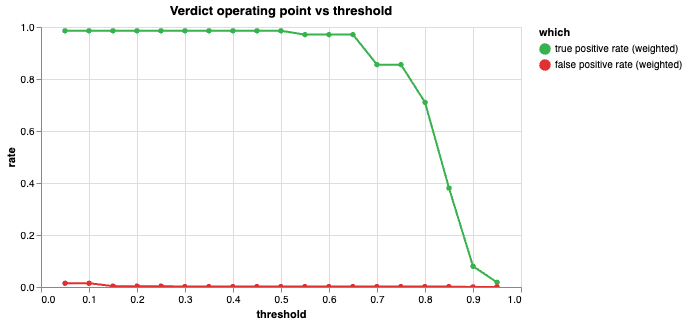

In [30]:
def confusion(frame, threshold):
    pred = frame.score >= threshold
    return pd.DataFrame({
        "labelled blocked": [int((pred & frame.truth).sum()), int((~pred & frame.truth).sum())],
        "labelled benign":  [int((pred & ~frame.truth).sum()), int((~pred & ~frame.truth).sum())],
    }, index=["predicted blocked", "predicted benign"])

print("threshold = 0.5, unweighted counts")
display(confusion(ev, 0.5))

rows = []
for t in np.round(np.arange(0.05, 1.0, 0.05), 2):
    pred = ev.score >= t
    tpr = ev.w[pred & ev.truth].sum() / ev.w[ev.truth].sum()
    fpr = ev.w[pred & ~ev.truth].sum() / ev.w[~ev.truth].sum()
    rows.append({"threshold": t, "rate": tpr, "which": "true positive rate (weighted)"})
    rows.append({"threshold": t, "rate": fpr, "which": "false positive rate (weighted)"})
sweep = pd.DataFrame(rows)

alt.Chart(sweep).mark_line(point=True).encode(
    x="threshold:Q",
    y=alt.Y("rate:Q", scale=alt.Scale(domain=[0, 1])),
    color=alt.Color("which:N", scale=alt.Scale(
        domain=["true positive rate (weighted)", "false positive rate (weighted)"],
        range=["#37b24d", "#e03131"])),
    tooltip=['threshold', 'rate', 'which']
).properties(width=480, height=260, title="Verdict operating point vs threshold").interactive()

Remember what weighted FPR means here: benign measurements outnumber blocked
ones ~10:1 in the population, so even a small weighted FPR is a large absolute
number of wrongly-flagged measurements. That asymmetry, not accuracy, is why
the rule LLRs below are the number worth fitting.

### Where the layers disagree with the analyst

For blocked labels, the mechanism names a layer. It should be the layer whose
blocked score drove the verdict, and its top rule should be compatible with
the mechanism.

In [15]:
blocked = ev[ev.truth].copy()
blocked["label_layer"] = blocked.mechanisms.str[0].str.split(".").str[0]
blocked["argmax_layer"] = blocked[["dns_blocked", "tcp_blocked", "tls_blocked"]].idxmax(axis=1).str.replace("_blocked", "")
blocked["argmax_rule"] = [getattr(r, f"top_{r.argmax_layer}_rule_id") for r in blocked.itertuples()]
blocked["layer_agrees"] = blocked.label_layer == blocked.argmax_layer

blocked[["measurement_uid", "target", "mechanisms", "score",
         "argmax_layer", "argmax_rule", "layer_agrees"]]

,measurement_uid,target,mechanisms,score,argmax_layer,argmax_rule,layer_agrees
3,20260729072259.172942_MM_webconnectivity_98276...,edge-mqtt.facebook.com,[tcp.timeout],0.75,tcp,failure_ctrl_ok,True
5,20260719085015.664751_VE_webconnectivity_680d9...,signal.org,[dns.injection.bogon],0.95,dns,bogon_not_in_ctrl,True
6,20260722184232.178120_CN_webconnectivity_09960...,b9vhe.com,[tls.reset.other],0.80,tls,failure_ctrl_ok_reset,True
7,20260802182140.105009_CN_webconnectivity_15118...,javextreme.net,[tls.reset.sni],0.80,tls,failure_ctrl_ok_reset,True
9,20260730074911.833431_DE_webconnectivity_0652c...,cine.to,[dns.nxdomain],0.90,dns,failure_ctrl_ok,True
11,20260712184737.043853_RU_webconnectivity_9752d...,proxify.com,[tls.timeout],0.70,tls,failure_ctrl_ok_other,True
13,20260712154212.866500_CN_webconnectivity_02dca...,slot-gacor-10.koko5000.it.com,[tls.reset.sni],0.90,dns,failure_ctrl_ok,False
21,20260708055827.573103_RU_webconnectivity_eb40a...,www.goldfishka.ru,[dns.injection.blockpage],1.00,dns,country_consistent_blockpage,True
23,20260717153706.549174_RU_webconnectivity_9cda0...,www.edf.org,[tls.timeout],0.70,tls,failure_ctrl_ok_other,True
25,20260706214540.399292_DE_webconnectivity_50156...,serienstream.to,[dns.injection.blockpage],0.90,dns,tls_inconsistent_not_in_ctrl,True


## 5. Per-rule log-likelihood ratios, conditioned per layer

This is the calibration path out of hand-set constants. The conditioning
matters: a rule's evidence is about **its own layer**, not the measurement's
overall verdict. Conditioning on the overall label gets both directions wrong:

- `tcp.connect_ok` fires on every TLS-blocked measurement (the SYN goes
  through; the reset comes later), so against the overall label it looks like
  weak evidence of blocking. Against *TCP* truth it is what it actually is:
  evidence that nothing happened at this layer.
- Worse for DNS: every non-DNS mechanism lands in the "blocked" class while
  the DNS rules correctly fired benign, dragging every benign DNS rule toward
  LR = 1 and making DNS look uninformative about the blocking it never claimed
  to detect.

So for a layer-$L$ rule $r$, with truth taken from the label's mechanism
taxonomy (a `tls.*` mechanism means blocked-at-TLS):

$$LR_r = \frac{P(\text{top rule} = r \mid \text{blocked at } L)}{P(\text{top rule} = r \mid \text{not blocked at } L)}$$

both sides restricted to measurements where the layer was **observed**: a row
whose $L$-rule is a mask (`no_*_data`, or discarded because DNS was untrusted
or TCP already blocked) says nothing about $L$ and enters neither class.
Multi-mechanism labels land in each layer they name.

Still LRs and not posteriors — the corpus oversamples positives, posteriors are
not estimable from it, the LR is invariant to the sampling rates. Two honesty
notes baked into the estimator:

- **Smoothing.** A rule never seen on layer-benign rows would give
  $LR = \infty$. Half a pseudo-observation each side (Jeffreys) keeps it
  finite and shrinks exactly the rules with the least data.
- **Winner censoring.** Only the *winning* rule per layer is recorded, so these
  are LRs for "rule won", not "rule fired". Fixing that needs the fired-set
  persistence from implementation plan §3.9; until then the LRs inherit the
  cascade's ordering.

In [16]:
# Layer truth from the mechanism taxonomy. A bare layer name ("tls") is a
# valid mechanism, so match the layer itself or any path under it.
for L in ("dns", "tcp", "tls"):
    ev[f"truth_{L}"] = ev.mechanisms.apply(
        lambda ms, L=L: any(m == L or m.startswith(L + ".") for m in ms))

# Rules through which a layer said nothing: no data, or discarded because an
# upstream layer failed. Mirrors Evidence.NONE / DISCARDED in
# oonipipeline/analysis/rules.py; '' is a row that predates the rule-id
# columns. These rows enter neither class for that layer.
UNOBSERVED = {
    "dns": {"", "none", "no_dns_data"},
    "tcp": {"", "none", "no_tcp_data", "ipv6_broken_probe", "dns_untrusted"},
    "tls": {"", "none", "no_tls_data", "dns_untrusted", "tcp_blocked"},
}

def rule_llrs(frame, layer):
    col, tcol = f"top_{layer}_rule_id", f"truth_{layer}"
    obs = frame[~frame[col].isin(UNOBSERVED[layer])]
    if not len(obs):
        return pd.DataFrame()
    wbar = obs.w.mean()
    def llr(f, rule):
        o = f[~f[col].isin(UNOBSERVED[layer])]
        num = (o.w[(o[col] == rule) & o[tcol]].sum() + 0.5 * wbar) / (o.w[o[tcol]].sum() + wbar)
        den = (o.w[(o[col] == rule) & ~o[tcol]].sum() + 0.5 * wbar) / (o.w[~o[tcol]].sum() + wbar)
        return np.log10(num / den)
    out = []
    for rule, g in obs.groupby(col):
        lo, hi = boot(frame, lambda f, rule=rule: llr(f, rule))
        out.append({
            "layer": layer, "rule_id": rule,
            "n_layer_blocked": int(g[tcol].sum()),
            "n_layer_benign": int((~g[tcol]).sum()),
            "log10_LR": llr(frame, rule), "ci_lo": lo, "ci_hi": hi,
        })
    return pd.DataFrame(out)

llr = pd.concat([rule_llrs(ev, l) for l in ("dns", "tcp", "tls")], ignore_index=True)
llr.sort_values("log10_LR", ascending=False).round(2)

,layer,rule_id,n_layer_blocked,n_layer_benign,log10_LR,ci_lo,ci_hi
14,tls,failure_ctrl_ok_reset,11,0,2.04,1.80,2.19
2,dns,bogon_not_in_ctrl,4,0,1.78,1.48,2.01
5,dns,failure_ctrl_ok,11,5,1.61,1.31,1.93
13,tls,failure_ctrl_ok_other,7,0,1.60,1.24,1.96
8,dns,tls_inconsistent_not_in_ctrl,3,1,1.55,1.17,1.91
3,dns,country_consistent_blockpage,1,0,1.53,1.26,1.80
11,tcp,failure_ctrl_ok,6,2,1.52,0.96,2.22
6,dns,failure_no_ctrl,1,0,1.51,1.26,1.75
0,dns,answer_matches_ctrl,0,1,1.22,0.94,1.49
10,tcp,failure_ctrl_also_failing,0,1,1.18,0.74,1.74


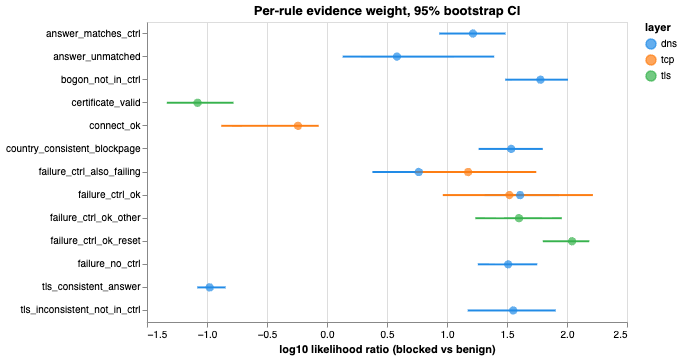

In [28]:
base = alt.Chart(llr).encode(
    y=alt.Y("rule_id:N", sort="-x", title=None),
    color=alt.Color("layer:N", scale=alt.Scale(range=["#228be6", "#fd7e14", "#37b24d"])),
)
(base.mark_rule(strokeWidth=2).encode(x="ci_lo:Q", x2="ci_hi:Q") +
 base.mark_point(filled=True, size=70).encode(
     x=alt.X("log10_LR:Q", title="log10 likelihood ratio (blocked vs benign)"))
).properties(width=480, height=20 * len(llr), title="Per-rule evidence weight, 95% bootstrap CI")

## 6. Feeding these back into `rules.py`

How the numbers become rule weights, and the gates before they should:

1. **The quantity.** Each rule's `log10_LR` is its evidence weight for
   *blocked vs benign*. The three-state triple generalises to per-state
   likelihoods $P(E \mid s)$ for $s \in \{blocked, down, ok\}$ — same
   estimator with `label == "down"` as its own class once there are enough
   `down` labels to matter (there is one in this corpus).
2. **The gates.** Do not promote a fitted weight while: the rule has fewer than
   ~30 labelled firings; its CI includes 0 (evidence indistinguishable from
   none); or the fired-set persistence from implementation plan §3.9 has not
   landed — fitting on winners bakes the current cascade order into the
   weights.
3. **The mechanics.** Weights change through a new `RULES_VERSION`, never by
   editing a rule in place, so historical rows remain attributable to the
   ruleset that scored them. Recalibration is then a join against
   `top_*_rule_id`, not a reprocessing run.
4. **The corpus grows or the intervals stay wide.** Every labelling session
   compounds: re-run this notebook with the new export and watch the CIs
   tighten. The `screen_negative` strata are where sensitivity hides; the
   labels there are each worth millions of measurements.

In [18]:
# Evidence cuts both ways: a blocking rule promotes on ci_lo > 0, a benign
# rule on ci_hi < 0. Only a CI straddling 0 is uninformative.
MIN_LABELS = 30
llr["n"] = llr.n_layer_blocked + llr.n_layer_benign
llr["gated"] = (llr.n >= MIN_LABELS) & ((llr.ci_lo > 0) | (llr.ci_hi < 0))
promotable = llr[llr.gated]
table = llr.sort_values(["layer", "log10_LR"], ascending=[True, False]).round(3)
print(f"rules meeting the promotion gates today: {len(promotable)} of {len(llr)}")
print()
print("suggested weights (informational until the gates pass):")
for r in table.itertuples():
    flag = "  OK " if r.Index in promotable.index else "  -- "
    print(f"{flag}{r.layer:4s} {r.rule_id:28s} log10_LR={r.log10_LR:+.2f}  "
          f"CI [{r.ci_lo:+.2f}, {r.ci_hi:+.2f}]  n={r.n_layer_blocked + r.n_layer_benign}")

rules meeting the promotion gates today: 3 of 15

suggested weights (informational until the gates pass):
  -- dns  bogon_not_in_ctrl            log10_LR=+1.78  CI [+1.49, +2.01]  n=4
  -- dns  failure_ctrl_ok              log10_LR=+1.61  CI [+1.31, +1.93]  n=16
  -- dns  tls_inconsistent_not_in_ctrl log10_LR=+1.55  CI [+1.17, +1.91]  n=4
  -- dns  country_consistent_blockpage log10_LR=+1.53  CI [+1.26, +1.80]  n=1
  -- dns  failure_no_ctrl              log10_LR=+1.51  CI [+1.26, +1.75]  n=1
  -- dns  answer_matches_ctrl          log10_LR=+1.22  CI [+0.94, +1.49]  n=1
  -- dns  failure_ctrl_also_failing    log10_LR=+0.77  CI [+0.38, +1.46]  n=2
  -- dns  answer_unmatched             log10_LR=+0.58  CI [+0.13, +1.39]  n=5
  OK dns  tls_consistent_answer        log10_LR=-0.98  CI [-1.08, -0.85]  n=89
  -- tcp  failure_ctrl_ok              log10_LR=+1.52  CI [+0.96, +2.22]  n=8
  -- tcp  failure_ctrl_also_failing    log10_LR=+1.18  CI [+0.74, +1.74]  n=1
  OK tcp  connect_ok              

## 7. What-if: thresholds and rule weights, head to head with fastpath

Two knobs decide what the pipeline flags, and they live in different places:

1. **The decision threshold** — where "blocked-leaning" begins on
   `greatest(dns, tcp, tls blocked)`. Presentation-level; changing it costs a
   config edit, no reprocessing.
2. **The per-rule blocked weights** in `analysis/rules.py`. Changing one moves
   every measurement whose *winning* rule it is, at whatever threshold.

Both are simulated here without touching ClickHouse. This works because a
measurement's `{layer}_blocked` *is* the blocked weight of its winning rule —
verified below — so a weight change re-scores the corpus in pandas. Rows that
predate the rule-id columns keep their stored scores and ignore weight tweaks;
they shrink the simulation, not bias it.

The deployed threshold is imported from the backend's
`oonimeasurements/scoring.py`, so the row marked `(deployed)` is today's
behaviour rather than an assumption. To change it for real: pick a row here,
then edit `BLOCKING_THRESHOLD` there and bump `SCORING_VERSION`.

**Promotion scenarios come from section 5 automatically.** A fitted LLR is in
log-odds units and a rule weight is in [0, 1], so they are converted through
the *deployed* calibration (section 8 refits it; this inverts what is live): the implied weight is the one whose calibrated
probability matches the rule's own evidence,

$$w_r = \operatorname{clip}\!\left(\frac{\pi_\ell + \text{llr}_r - \text{INTERCEPT}}{\text{SLOPE}},\; 0,\; 1\right)$$

with $\pi_\ell$ the corpus prior for that layer. That keeps one score scale, so
promoted and hand-set rules stay directly comparable. Two scenarios are built
from it: promoting only the rules past the gates, and promoting every rule with
a fitted LLR — the literal "use LLR everywhere" option, priced.

This is a form of [Platt scaling](https://en.wikipedia.org/wiki/Platt_scaling).

**How to tweak:** edit `THRESHOLDS` and `WHAT_IF` in the next cell. `WHAT_IF`
is for ad-hoc questions the fitted values do not answer; leave it `{}` to see
only the promotion scenarios.

**What this cannot simulate:** changes to rule *conditions* or *order*, and
new rules — those need a reprocess. And only the winning rule per layer is
recorded, so a demoted rule's runner-up is invisible: treat a simulated demotion
as a lower bound on the score, not an exact rescoring.

In [19]:
# Deployed weights, from the registry when importable, else the snapshot below.
try:
    import sys; sys.path.insert(0, "../oonipipeline/src")
    from oonipipeline.analysis.rules import LAYER_RULES
    RULE_WEIGHTS = {f"{L}.{r.rule_id}": r.blocked
                    for L, rules in LAYER_RULES.items() for r in rules}
    print(f"rule registry imported: {len(RULE_WEIGHTS)} rules")
except ImportError:
    RULE_WEIGHTS = {
        "dns.no_dns_data": 0.0, "dns.country_consistent_blockpage": 1.0,
        "dns.tls_consistent_answer": 0.0, "dns.bogon_not_in_ctrl": 0.95,
        "dns.bogon_in_ctrl": 0.1, "dns.tls_inconsistent_not_in_ctrl": 0.9,
        "dns.answer_matches_ctrl": 0.0, "dns.answer_asn_matches_ctrl": 0.2,
        "dns.failure_ctrl_also_failing": 0.1, "dns.failure_ctrl_ok": 0.9,
        "dns.failure_no_ctrl": 0.5, "dns.answer_unmatched": 0.75,
        "tcp.no_tcp_data": 0.0, "tcp.connect_ok": 0.0, "tcp.ipv6_broken_probe": 0.0,
        "tcp.failure_ctrl_ok": 0.75, "tcp.dns_untrusted": 0.0,
        "tcp.failure_ctrl_also_failing": 0.25,
        "tls.no_tls_data": 0.0, "tls.certificate_valid": 0.0,
        "tls.failure_ctrl_ok_ssl": 0.9, "tls.failure_ctrl_ok_reset": 0.8,
        "tls.failure_ctrl_ok_other": 0.7, "tls.dns_untrusted": 0.0,
        "tls.tcp_blocked": 0.0, "tls.failure_ctrl_also_failing": 0.2,
    }
    print("registry not importable; using the hardcoded snapshot")

def rescore(frame, overrides):
    """Overall blocked score per measurement under modified rule weights.
    Rows without rule ids fall back to their stored layer scores."""
    w = {**RULE_WEIGHTS, **overrides}
    layer_scores = []
    for L in ("dns", "tcp", "tls"):
        mapped = frame[f"top_{L}_rule_id"].map(
            lambda rid, L=L: w.get(f"{L}.{rid}", np.nan))
        layer_scores.append(mapped.fillna(frame[f"{L}_blocked"]))
    return pd.concat(layer_scores, axis=1).max(axis=1)

# The identity this all rests on: with no overrides, reconstruction must
# reproduce the stored scores wherever rule ids exist.
have_ids = ~(ev[["top_dns_rule_id", "top_tcp_rule_id", "top_tls_rule_id"]] == "").any(axis=1)
drift = (rescore(ev, {}) - ev.score)[have_ids].abs().max()
assert drift < 1e-3, f"reconstruction drifts from stored scores by {drift}"
print(f"reconstruction exact on the {int(have_ids.sum())} fully-attributed rows "
      f"(max drift {drift:.2e}); {int((~have_ids).sum())} rows pinned to stored scores")

rule registry imported: 26 rules
reconstruction exact on the 124 fully-attributed rows (max drift 2.38e-08); 2 rows pinned to stored scores


In [20]:
# The threshold the service actually deploys, so "analysis @ DEPLOYED" below is
# today's behaviour and not an assumption. Falls back to 0.5 if the backend
# checkout is not alongside this repo.
try:
    sys.path.insert(0, "../../backend/ooniapi/services/oonimeasurements/src")
    from oonimeasurements.scoring import (BLOCKING_THRESHOLD as DEPLOYED,
                                          SCORING_VERSION, Calibration)
    CAL_PI, CAL_LAM = Calibration.INTERCEPT, Calibration.SLOPE
    print(f"deployed threshold {DEPLOYED} (scoring_version {SCORING_VERSION}), "
          f"calibration {CAL_PI:+.4f} / {CAL_LAM:+.4f}")
except ImportError:
    DEPLOYED, SCORING_VERSION = 0.5, "?"
    CAL_PI, CAL_LAM = -2.3594, 4.7413
    print(f"backend not found; assuming threshold {DEPLOYED}")

# ------------------------- edit these and re-run -------------------------
THRESHOLDS = sorted({0.3, DEPLOYED, 0.7})

WHAT_IF = {}   # ad-hoc overrides, e.g. {"dns.answer_unmatched": 0.30}
# -------------------------------------------------------------------------

# Per-layer prior log10-odds, weighted so it is a population rate.
layer_prior = {}
for L in ("dns", "tcp", "tls"):
    p = float(np.average(ev[f"truth_{L}"], weights=ev.w))
    p = min(max(p, 1e-6), 1 - 1e-6)
    layer_prior[L] = np.log10(p / (1 - p))

# The [0,1] weight matching a rule's fitted evidence. Inverts the deployed
# calibration, so a promoted rule and a hand-set one land on the same scale and
# rescore() needs no changes. Clipping at the ends is the honest limit: the
# score cannot express evidence stronger than the calibration's own range.
def implied_weight(layer, llr_value):
    log_odds = layer_prior[layer] + llr_value
    return float(np.clip((log_odds - CAL_PI) / CAL_LAM, 0.0, 1.0))

FITTED = {f"{r.layer}.{r.rule_id}": implied_weight(r.layer, r.log10_LR)
          for r in llr.itertuples()}
GATED = {f"{r.layer}.{r.rule_id}": implied_weight(r.layer, r.log10_LR)
         for r in llr.itertuples() if r.gated}

moved = {k: (RULE_WEIGHTS.get(k), round(v, 3)) for k, v in GATED.items()
         if abs(RULE_WEIGHTS.get(k, 0) - v) > 0.005}
print(f"{len(GATED)} rules past the gates, {len(moved)} of them would actually move:")
for k, (was, now) in sorted(moved.items()):
    print(f"    {k:35s} {was} -> {now}")
if not moved:
    print("    none - every gated rule already sits where the evidence puts it")

scenarios = {"fastpath anomaly": ("__fastpath", None)}
ev["__fastpath"] = (ev.sampling_stratum == "screen_positive").astype(float)
for t in THRESHOLDS:
    tag = f"{t} (deployed)" if t == DEPLOYED else f"{t}"
    scenarios[f"analysis @ {tag}"] = ("score", t)

ev["__gated"] = rescore(ev, GATED)
scenarios[f"promote gated ({len(GATED)}) @ {DEPLOYED}"] = ("__gated", DEPLOYED)
ev["__fitted"] = rescore(ev, FITTED)
scenarios[f"promote ALL fitted ({len(FITTED)}) @ {DEPLOYED}"] = ("__fitted", DEPLOYED)

if WHAT_IF:
    ev["__whatif"] = rescore(ev, WHAT_IF)
    for t in THRESHOLDS:
        scenarios[f"what-if @ {t}"] = ("__whatif", t)

deployed threshold 0.5 (scoring_version 2), calibration -2.3594 / +4.7413
3 rules past the gates, 1 of them would actually move:
    tcp.connect_ok                      0.0 -> 0.127


Column meanings: **sensitivity** — share of truly blocked measurements flagged
(weighted, so it is a population share, not a corpus share). **specificity** —
share of benign measurements not flagged. **PPV** — share of flagged
measurements that are truly blocked, i.e. what an analyst opening a flagged
measurement should expect. **flagged / frame** and **false alarms / frame** —
estimated absolute volumes over the sampling frame, which is where a
threshold's real cost shows: benign traffic outnumbers blocked ~10:1, so a
point of specificity is worth more flagged-queue sanity than a point of
sensitivity.

Fastpath has no threshold — it is one fixed operating point — so it appears
once, and the question for every other row is whether it beats fastpath on
both axes at once or trades one for the other.

In [21]:
def operating_point(frame, col, thr):
    flag = frame[col] >= (thr if thr is not None else 0.5)
    wB, wN = frame.w[frame.truth].sum(), frame.w[~frame.truth].sum()
    flagged = frame.w[flag].sum()
    return {
        "sensitivity": frame.w[flag & frame.truth].sum() / wB,
        "specificity": frame.w[~flag & ~frame.truth].sum() / wN,
        "ppv": frame.w[flag & frame.truth].sum() / flagged if flagged else np.nan,
        "flagged / frame": flagged,
        "false alarms / frame": frame.w[flag & ~frame.truth].sum(),
    }

rows = []
for name, (col, thr) in scenarios.items():
    pt = operating_point(ev, col, thr)
    s_lo, s_hi = boot(ev, lambda f, c=col, t=thr: operating_point(f, c, t)["sensitivity"])
    p_lo, p_hi = boot(ev, lambda f, c=col, t=thr: operating_point(f, c, t)["specificity"])
    rows.append({
        "scenario": name,
        "sensitivity": f'{pt["sensitivity"]:.1%} [{s_lo:.0%}-{s_hi:.0%}]',
        "specificity": f'{pt["specificity"]:.2%} [{p_lo:.1%}-{p_hi:.1%}]',
        "ppv": f'{pt["ppv"]:.1%}',
        "flagged / frame": f'{pt["flagged / frame"]:,.0f}',
        "false alarms / frame": f'{pt["false alarms / frame"]:,.0f}',
        "_sens": pt["sensitivity"], "_spec": pt["specificity"],
    })
summary = pd.DataFrame(rows)

fp = summary[summary.scenario == "fastpath anomaly"].iloc[0]
def verdict(name, sens, spec):
    if name == "fastpath anomaly":
        return "reference"
    if sens >= fp["_sens"] and spec >= fp["_spec"]:
        return "dominates fastpath"
    if sens < fp["_sens"] and spec < fp["_spec"]:
        return "dominated BY fastpath"
    return "trade-off"
summary["vs fastpath"] = [verdict(n, se, sp) for n, se, sp
                          in zip(summary.scenario, summary["_sens"], summary["_spec"])]
summary.drop(columns=["_sens", "_spec"])

,scenario,sensitivity,specificity,ppv,flagged / frame,false alarms / frame,vs fastpath
0,fastpath anomaly,67.0% [45%-100%],99.38% [98.8%-99.9%],90.7%,"8,901,127","823,466",reference
1,analysis @ 0.3,98.5% [95%-100%],99.84% [99.5%-100.0%],98.2%,"12,092,155","215,672",dominates fastpath
2,analysis @ 0.5 (deployed),98.5% [95%-100%],99.84% [99.5%-100.0%],98.2%,"12,092,155","215,672",dominates fastpath
3,analysis @ 0.7,85.5% [72%-94%],99.84% [99.5%-100.0%],98.0%,"10,523,669","215,672",dominates fastpath
4,promote gated (3) @ 0.5,98.5% [95%-100%],99.84% [99.5%-100.0%],98.2%,"12,092,155","215,672",dominates fastpath
5,promote ALL fitted (15) @ 0.5,76.1% [57%-90%],100.00% [100.0%-100.0%],100.0%,"9,167,404",0,dominates fastpath


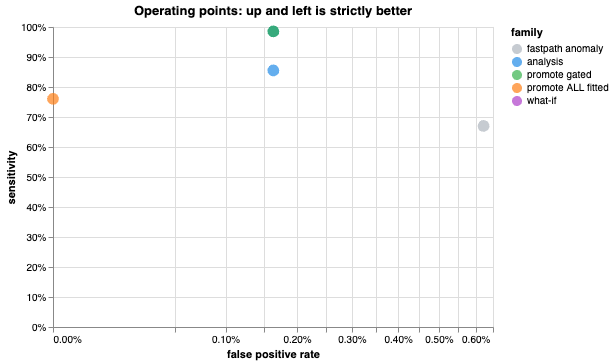

In [31]:
pts = pd.DataFrame([
    {"scenario": name, "sensitivity": operating_point(ev, col, thr)["sensitivity"],
     "false positive rate": 1 - operating_point(ev, col, thr)["specificity"],
     "family": name.split(" (")[0].split(" @")[0]}
    for name, (col, thr) in scenarios.items()
])
alt.Chart(pts).mark_point(filled=True, size=140).encode(
    x=alt.X("false positive rate:Q", scale=alt.Scale(type="sqrt"),
            axis=alt.Axis(format="%")),
    y=alt.Y("sensitivity:Q", scale=alt.Scale(domain=[0, 1]), axis=alt.Axis(format="%")),
    color=alt.Color("family:N", scale=alt.Scale(
        domain=["fastpath anomaly", "analysis", "promote gated",
                "promote ALL fitted", "what-if"],
        range=["#adb5bd", "#228be6", "#37b24d", "#fd7e14", "#ae3ec9"])),
    tooltip=["scenario", alt.Tooltip("sensitivity", format=".1%"),
             alt.Tooltip("false positive rate", format=".2%")],
).properties(width=440, height=300,
             title="Operating points: up and left is strictly better")

A `[100%-100%]` interval is the bootstrap hitting a boundary: every resample
flags every blocked label, so the resampler cannot manufacture a miss. Read it
as *no counterexample among the blocked labels*, with a rule-of-three bound on
the miss rate of about $3/n_{blocked}$ — not as certainty.

The two promotion rows are the migration question made concrete. If
`promote gated` matches `analysis`, the rules with enough evidence already sit
where the evidence puts them and promoting them is a no-op worth doing for
tidiness, not for accuracy. If `promote ALL fitted` is *worse*, that is the
corpus saying it cannot yet support a free parameter per rule — which is the
answer to "can I just use the LLRs everywhere", updated on every run.

Reading the table: a **dominates fastpath** row is a free win — flip to it.
A **trade-off** row is a policy question: the false-alarms column prices one
side of it in absolute measurements. And any `WHAT_IF` scenario that moves
sensitivity without touching the false-alarm column (or vice versa) tells you
that rule only ever wins on one side of the truth — which is what its LLR in
section 5 already said, now in operational units.

## 8. Fitting the published probability

The API publishes `blocked_probability` per measurement and
`blocked_probability_mean` per aggregation cell. Those come from constants in
the backend's `scoring.py`, and this section is where the constants come from.
Refit here, paste there.

The map is a logistic in the fuzzy score:

$$\log_{10}\text{odds}(\text{blocked}) = \pi + \lambda \cdot \text{score}, \qquad P = \frac{1}{1 + 10^{-(\pi + \lambda\,\text{score})}}$$

Three things make this different from calling `LogisticRegression().fit()`:

**Fit with the sampling weights.** The corpus oversamples positives roughly
20:1 by design. An unweighted fit describes the corpus, not the network, and
overstates blocking by about that factor. The weights convert one to the other.

**Penalise the slope.** The classes are nearly separable at this corpus size,
which sends an unpenalised logistic slope toward infinity — the bootstrap
interval on it runs past 6000 and leave-one-out log loss blows up to 8.2. The
ridge below is *selected* by leave-one-out weighted log loss, not chosen.

**Report the interval.** $\lambda$ is a published constant that decides what
numbers users see, so it travels with its uncertainty and the corpus it came
from.

$\lambda$ here is large (~4.7) only because the input is a hand-set score in
[0, 1] rather than a log-LR. When the rule weights become fitted LLRs it should
land near 1, and a $\lambda$ far from 1 at that point means the LLRs are
miscalibrated rather than the map.

In [23]:
from scipy.optimize import minimize

LN10 = np.log(10)
cal = ev.dropna(subset=["score"]).copy()
S, Y, W = cal.score.values, cal.truth.values.astype(float), cal.w.values

def fit(s, y, w, ridge):
    """Weighted, ridge-penalised logistic in log10-odds space."""
    def nll(th):
        z = (th[0] + th[1] * s) * LN10
        return float(np.sum(w * (np.logaddexp(0, z) - y * z)) / w.sum()
                     + ridge * th[1] ** 2)
    return minimize(nll, [-1.2, 1.0], method="Nelder-Mead",
                    options=dict(xatol=1e-9, fatol=1e-12, maxiter=8000)).x

def loo_log_loss(ridge):
    tot = den = 0.0
    for i in range(len(S)):
        m = np.ones(len(S), bool); m[i] = False
        pi, lam = fit(S[m], Y[m], W[m], ridge)
        z = (pi + lam * S[i]) * LN10
        tot += W[i] * (np.logaddexp(0, z) - Y[i] * z); den += W[i]
    return tot / den

grid = [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
losses = {r: loo_log_loss(r) for r in grid}
RIDGE = min(losses, key=losses.get)
for r, l in losses.items():
    print(f"  ridge={r:<8} LOO log loss={l:.5f}{'   <- selected' if r == RIDGE else ''}")
PI, LAM = fit(S, Y, W, RIDGE)
print()
print(f"fitted: intercept={PI:+.4f}  slope={LAM:+.4f}  (log10-odds units)")

  ridge=0.0      LOO log loss=0.02909
  ridge=0.0005   LOO log loss=0.02376   <- selected
  ridge=0.001    LOO log loss=0.02639
  ridge=0.002    LOO log loss=0.03216
  ridge=0.005    LOO log loss=0.04784
  ridge=0.01     LOO log loss=0.06931
  ridge=0.02     LOO log loss=0.10259
  ridge=0.05     LOO log loss=0.16550

fitted: intercept=-2.3424  slope=+4.5615  (log10-odds units)


In [24]:
boot_fits = np.array([
    fit(*(lambda i: (S[i], Y[i], W[i]))(rng.integers(0, len(S), len(S))), RIDGE)
    for _ in range(400)
])
PI_CI = tuple(np.percentile(boot_fits[:, 0], [2.5, 97.5]).round(3))
LAM_CI = tuple(np.percentile(boot_fits[:, 1], [2.5, 97.5]).round(3))
print(f"intercept 95% CI {PI_CI}")
print(f"slope     95% CI {LAM_CI}")

prob = lambda x: 1 / (1 + 10 ** (-(PI + LAM * x)))
pd.DataFrame({"score": sorted(set(np.round(S, 3))),
              "P(blocked)": [round(prob(x), 4) for x in sorted(set(np.round(S, 3)))],
              "n labelled": [int((np.round(S, 3) == x).sum())
                             for x in sorted(set(np.round(S, 3)))]})

intercept 95% CI (-2.547, -2.084)
slope     95% CI (4.016, 5.215)


,score,P(blocked),n labelled
0,0.00,0.0045,78
1,0.10,0.0128,2
2,0.25,0.0591,1
3,0.50,0.4646,1
4,0.70,0.8764,7
5,0.75,0.9230,6
6,0.80,0.9530,6
7,0.90,0.9830,20
8,0.95,0.9899,4
9,1.00,0.9940,1


The reliability diagram is the check that matters: bin measurements by the
probability we would publish, and the observed blocked share in each bin should
track the diagonal. Bins are weighted, so "observed" is a population share
rather than a corpus share. Sparse bins are the honest limit here, not a bug —
they are why the published range carries a caveat.

,bin,n,predicted,observed
0,0.00-0.05,80,0.005,0.001
1,0.05-0.20,1,0.059,0.000
2,0.20-0.50,1,0.465,1.000
3,0.80-0.95,13,0.902,1.000
4,0.95-1.00,31,0.970,0.975


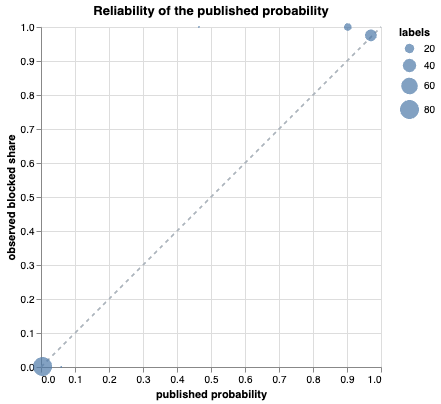

In [32]:
cal["p"] = prob(cal.score)
edges = [0, 0.05, 0.2, 0.5, 0.8, 0.95, 1.0]
rows = []
for lo, hi in zip(edges, edges[1:]):
    b = cal[(cal.p >= lo) & (cal.p < hi)] if hi < 1.0 else cal[cal.p >= lo]
    if not len(b):
        continue
    rows.append({"bin": f"{lo:.2f}-{hi:.2f}", "n": len(b),
                 "predicted": float(np.average(b.p, weights=b.w)),
                 "observed": float(np.average(b.truth, weights=b.w))})
rel = pd.DataFrame(rows)

diag = alt.Chart(pd.DataFrame({"x": [0, 1]})).mark_line(
    strokeDash=[4, 4], color="#adb5bd").encode(x="x:Q", y="x:Q")
pts = alt.Chart(rel).mark_point(filled=True).encode(
    x=alt.X("predicted:Q", scale=alt.Scale(domain=[0, 1]), title="published probability"),
    y=alt.Y("observed:Q", scale=alt.Scale(domain=[0, 1]), title="observed blocked share"),
    size=alt.Size("n:Q", title="labels"),
    tooltip=["bin", "n", alt.Tooltip("predicted", format=".3f"),
             alt.Tooltip("observed", format=".3f")])
display(rel.round(3))
(diag + pts).properties(width=340, height=340, title="Reliability of the published probability")

### Paste this into the service

`scoring.Calibration` in the backend. Bump `SCORING_VERSION` in the same edit:
a probability produced under a different fit is a different quantity, and the
version is what lets a stored or exported verdict say which one it was.

In [26]:
try:
    deployed = f"{Calibration.INTERCEPT:+.4f} / {Calibration.SLOPE:+.4f}"
except NameError:
    deployed = "not importable"
print(f"    INTERCEPT = {PI:.4f}")
print(f"    SLOPE = {LAM:.4f}")
print(f"    INTERCEPT_CI = {PI_CI}")
print(f"    SLOPE_CI = {LAM_CI}")
print(f"    RIDGE = {RIDGE}")
print(f"    LOO_LOG_LOSS = {losses[RIDGE]:.5f}")
print(f'    CORPUS = "{len(cal)} adjudicated labels ({int(Y.sum())} blocked)"')
print()
print(f"# currently deployed: {deployed}")
print(f"# threshold {DEPLOYED} sits at P = {prob(DEPLOYED):.3f}"
      f"  (near 0.5 means publishing probabilities changes no decisions)")

    INTERCEPT = -2.3424
    SLOPE = 4.5615
    INTERCEPT_CI = (-2.547, -2.084)
    SLOPE_CI = (4.016, 5.215)
    RIDGE = 0.0005
    LOO_LOG_LOSS = 0.02376
    CORPUS = "126 adjudicated labels (45 blocked)"

# currently deployed: -2.3594 / +4.7413
# threshold 0.5 sits at P = 0.465  (near 0.5 means publishing probabilities changes no decisions)
